### This notebook contains a single-layer exact GP regression model

In [1]:
import torch
import numpy as np
import gpytorch
import pandas as pd
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from deep_gp.gptorch_example import ExactGPModel
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# load data
features = pd.read_csv('../features.csv')
targets = pd.read_csv('../targets.csv')

data = features.merge(targets[['study_id','case_ISUP']], on='study_id')

X = data.drop(['study_id','patient_id','case_ISUP'], axis=1)
y = data['case_ISUP']


In [3]:

df = X.copy() 
df["case_ISUP"] = y

#  Reduce class 0 via nearest neighbors to other classes

idx_class0 = df.index[df["case_ISUP"] == 0]

selected_class0 = []

for cls in range(1, 6):
    print(f"Processing class {cls}")
    idx_cls = df.index[df["case_ISUP"] == cls]

    knn = NearestNeighbors(n_neighbors=1)
    knn.fit(df.loc[idx_class0, X.columns])

    distances, indices = knn.kneighbors(df.loc[idx_cls, X.columns])
    nearest_idx0 = idx_class0[indices.flatten()]
    selected_class0.extend(nearest_idx0)

selected_class0 = list(set(selected_class0))

print(f"\nOriginal class 0 count: {len(idx_class0)}")
print(f"New class 0 count: {len(selected_class0)}")

# New reduced dataset
df_new = pd.concat([
    df[df["case_ISUP"] != 0],      # keep all minority classes
    df.loc[selected_class0]        # keep only selected class-0 samples
])

print("\nFinal class counts BEFORE SMOTE:")
print(df_new["case_ISUP"].value_counts().sort_index())


# SMOTE only for classes 3, 4, 5

X_smote = df_new.drop(columns=["case_ISUP"])
y_smote = df_new["case_ISUP"]

sampling_strategy = {
    3: 150,
    4: 150,
    5: 150
}

sm = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=3,
    random_state=42
)

X_resampled, y_resampled = sm.fit_resample(X_smote, y_smote)

df_resampled = pd.concat([
    pd.DataFrame(X_resampled, columns=X_smote.columns),
    pd.Series(y_resampled, name="case_ISUP")
], axis=1)

print("\nFinal class counts AFTER SMOTE:")
print(df_resampled["case_ISUP"].value_counts().sort_index())


Processing class 1
Processing class 2
Processing class 3
Processing class 4
Processing class 5

Original class 0 count: 589
New class 0 count: 262

Final class counts BEFORE SMOTE:
case_ISUP
0    262
1    157
2    154
3     69
4     27
5     35
Name: count, dtype: int64

Final class counts AFTER SMOTE:
case_ISUP
0    262
1    157
2    154
3    150
4    150
5    150
Name: count, dtype: int64


In [4]:
X_balanced = df_resampled.drop(columns=["case_ISUP"])
y_balanced = df_resampled["case_ISUP"]

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

# Scale target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()


In [ ]:
results = []

pca_components_list = [10, 20, 30, 40, 50]
kernels = ["matern", "rbf_ard"]

for n_comp in pca_components_list:
    print(f"\n PCA = {n_comp} components")
    
    # PCA transform
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
    X_test_tensor  = torch.tensor(X_test_pca,  dtype=torch.float32)

    y_train_scaled = scaler_y.transform(y_train.values.reshape(-1,1)).ravel()
    y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()

    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
    y_test_tensor  = torch.tensor(y_test_scaled,  dtype=torch.float32)

    for kernel in kernels:
        print(f"\n--- Kernel: {kernel} ---")

        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        model = ExactGPModel(X_train_tensor, y_train_tensor, likelihood, kernel_type=kernel)

        model.train()
        likelihood.train()

        optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
        mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

        # Train GP
        for i in range(150):
            optimizer.zero_grad()
            output = model(X_train_tensor)
            loss = -mll(output, y_train_tensor)
            loss.backward()
            optimizer.step()

        # Predict
        model.eval()
        likelihood.eval()

        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            preds = model(X_test_tensor)

        mean_scaled = preds.mean.numpy()
        var_scaled  = preds.variance.numpy()
        std_scaled  = np.sqrt(var_scaled)

        # Back to ISUP scale
        mean = scaler_y.inverse_transform(mean_scaled.reshape(-1,1)).ravel()
        std  = std_scaled * scaler_y.scale_[0]

        y_test_original = y_test.values

        mse = mean_squared_error(y_test_original, mean)
        r2  = r2_score(y_test_original, mean)
        mean_unc = std.mean()

        print(f"MSE: {mse:.4f} | R²: {r2:.4f} | Mean Uncertainty: {mean_unc:.4f}")

        results.append([n_comp, kernel, mse, r2, mean_unc])

# Convert results to DataFrame
import pandas as pd
df_results = pd.DataFrame(results, columns=["PCA", "Kernel", "MSE", "R2", "Mean_Uncertainty"])
print("\n SUMMARY")
print(df_results)



 PCA = 10 components

--- Kernel: matern ---
MSE: 1.7305 | R²: 0.4752 | Mean Uncertainty: 1.3814

--- Kernel: rbf_ard ---
MSE: 1.7205 | R²: 0.4782 | Mean Uncertainty: 1.4434

 PCA = 20 components

--- Kernel: matern ---
MSE: 1.2060 | R²: 0.6343 | Mean Uncertainty: 1.2973

--- Kernel: rbf_ard ---
MSE: 1.2477 | R²: 0.6216 | Mean Uncertainty: 1.3701

 PCA = 30 components

--- Kernel: matern ---
MSE: 1.1337 | R²: 0.6562 | Mean Uncertainty: 1.2937

--- Kernel: rbf_ard ---
MSE: 1.1424 | R²: 0.6535 | Mean Uncertainty: 1.2988

 PCA = 40 components

--- Kernel: matern ---
MSE: 1.0542 | R²: 0.6803 | Mean Uncertainty: 1.2364

--- Kernel: rbf_ard ---
MSE: 1.1139 | R²: 0.6622 | Mean Uncertainty: 1.2822

 PCA = 50 components

--- Kernel: matern ---
MSE: 1.0849 | R²: 0.6710 | Mean Uncertainty: 1.2419

--- Kernel: rbf_ard ---
MSE: 1.1199 | R²: 0.6604 | Mean Uncertainty: 1.2250

================ SUMMARY ================
   PCA   Kernel       MSE        R2  Mean_Uncertainty
0   10   matern  1.730539  0

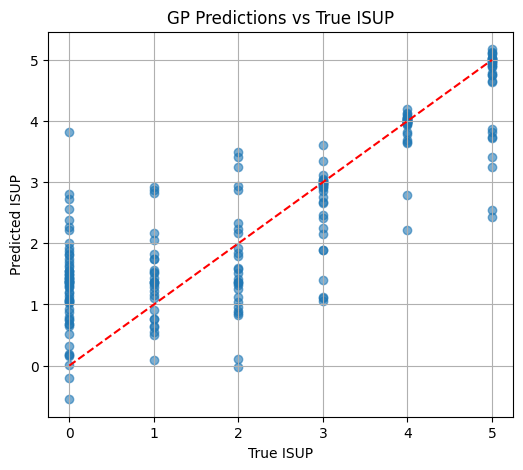

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_original, mean, alpha=0.6)
plt.plot([0,5],[0,5], 'r--')
plt.xlabel("True ISUP")
plt.ylabel("Predicted ISUP")
plt.title("GP Predictions vs True ISUP")
plt.grid(True)
plt.show()


In [ ]:
best = df_results.sort_values("R2", ascending=False).iloc[0]
print("\n BEST MODEL FOUND ")
print(best)



===== BEST MODEL FOUND =====
PCA                       40
Kernel                matern
MSE                 1.054181
R2                  0.680292
Mean_Uncertainty    1.236353
Name: 6, dtype: object
